In [56]:
# pip install kagglehub

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import kagglehub

In [58]:
from google.colab import userdata
userdata.get('KAGGLE_API_TOKEN')
from kagglehub import KaggleDatasetAdapter

file_path = "bank_churn_dataset.csv"

bank = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "thuandao/bank-customer-behavior-and-churn-dataset", file_path)
# bank.columns

Using Colab cache for faster access to the 'bank-customer-behavior-and-churn-dataset' dataset.


In [59]:
bank.info()
bank.select_dtypes(np.number).describe()
bank.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member           80000 non-null

,0
id,0
full_name,0
credit_sco,0
gender,0
age,0
occupation,0
balance,0
monthly_ir,0
address,0
origin_province,0


In [60]:
bank['created_date'] = pd.to_datetime(bank['created_date'], format = '%d/%m/%Y', errors="coerce")
bank['last_active_date'] = pd.to_datetime(bank['last_active_date'], format = '%d/%m/%Y', errors="coerce")
bank_cleaned = bank.drop(columns=['id', 'full_name'])
bank_cleaned.to_csv("Bank_Cleaned.csv", index=False)

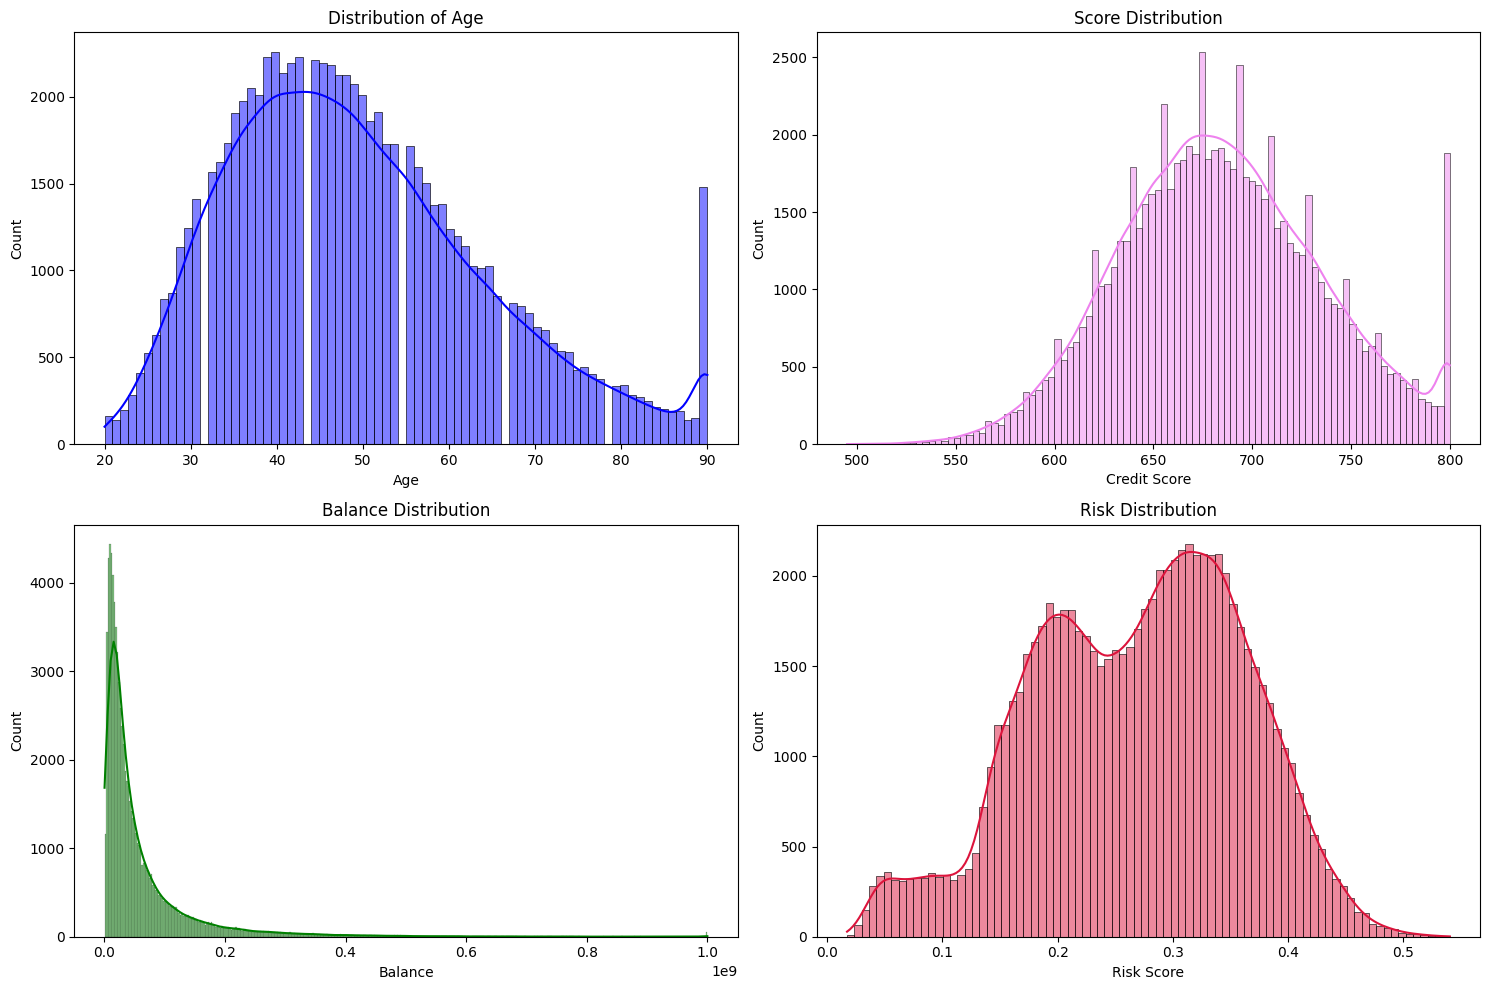

In [61]:
figs, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(bank['age'], kde=True, ax=axes[0,0], color='blue')
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_title("Distribution of Age")


sns.histplot(bank['credit_sco'], kde=True, ax=axes[0,1], color='violet')
axes[0, 1].set_xlabel("Credit Score")
axes[0, 1].set_title("Score Distribution")


sns.histplot(bank['balance'], kde=True, ax=axes[1,0], color='green')
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_title("Balance Distribution")


sns.histplot(bank['risk_score'], kde=True, ax=axes[1,1], color='crimson')
axes[1, 1].set_xlabel("Risk Score")
axes[1, 1].set_title("Risk Distribution")

plt.tight_layout()
plt.show()

Trend Analysis with Line Plots


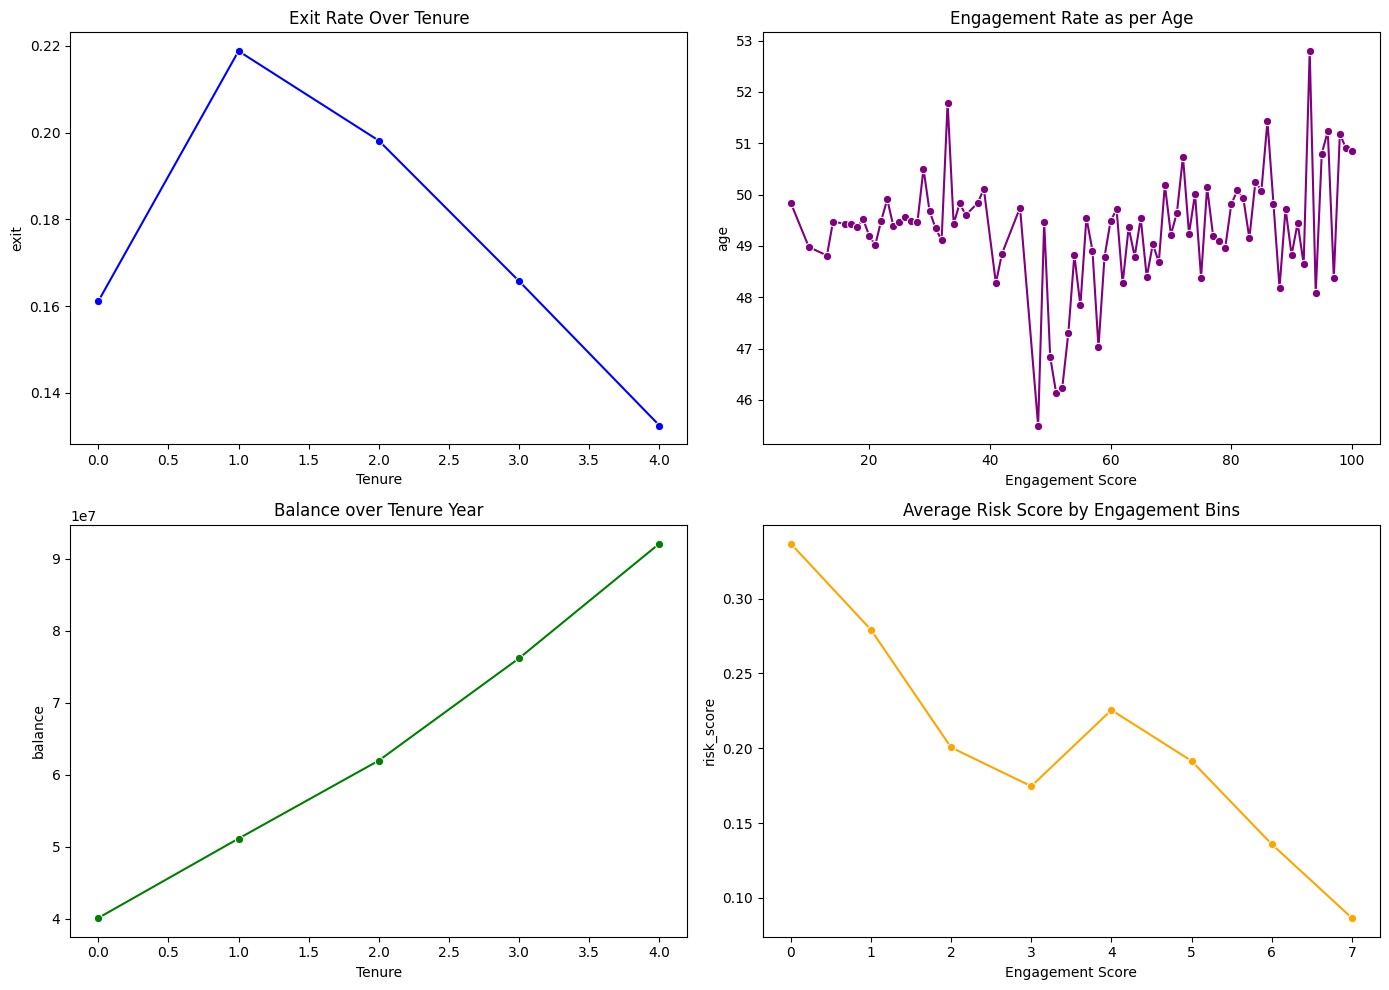

In [62]:
print("Trend Analysis with Line Plots")

figs, axes = plt.subplots(2, 2, figsize=(14, 10))

tenure_data = bank.groupby('tenure_ye')['exit'].mean().reset_index()
sns.lineplot(data=tenure_data, x='tenure_ye', y='exit', ax=axes[0,0], color='blue', marker='o')
axes[0, 0].set_xlabel("Tenure")
axes[0, 0].set_title("Exit Rate Over Tenure")


engagement_rate = bank.groupby('engagement_score')['age'].mean().reset_index()
sns.lineplot(data=engagement_rate, x='engagement_score', y='age', ax=axes[0,1], color='purple', marker='o')
axes[0, 1].set_xlabel("Engagement Score")
axes[0, 1].set_title("Engagement Rate as per Age")


balance_data = bank.groupby('tenure_ye')['balance'].mean().reset_index()
sns.lineplot(data=balance_data, x='tenure_ye', y='balance', ax=axes[1,0], color='green', marker='o')
axes[1, 0].set_xlabel("Tenure")
axes[1, 0].set_title("Balance over Tenure Year")


bank['engagement_bins'] = pd.cut(bank['engagement_score'], bins=8)
risk_rate = bank.groupby('engagement_bins', observed=True)['risk_score'].mean().reset_index()
sns.lineplot(data=risk_rate, x=range(len(risk_rate)), y='risk_score', ax=axes[1,1], color='orange', marker='o')
axes[1, 1].set_xticks(range(len(risk_rate)))
axes[1, 1].set_xlabel("Engagement Score")
axes[1, 1].set_title("Average Risk Score by Engagement Bins")


plt.tight_layout()
plt.show()

Plots to highlight actionable categorical churn drivers


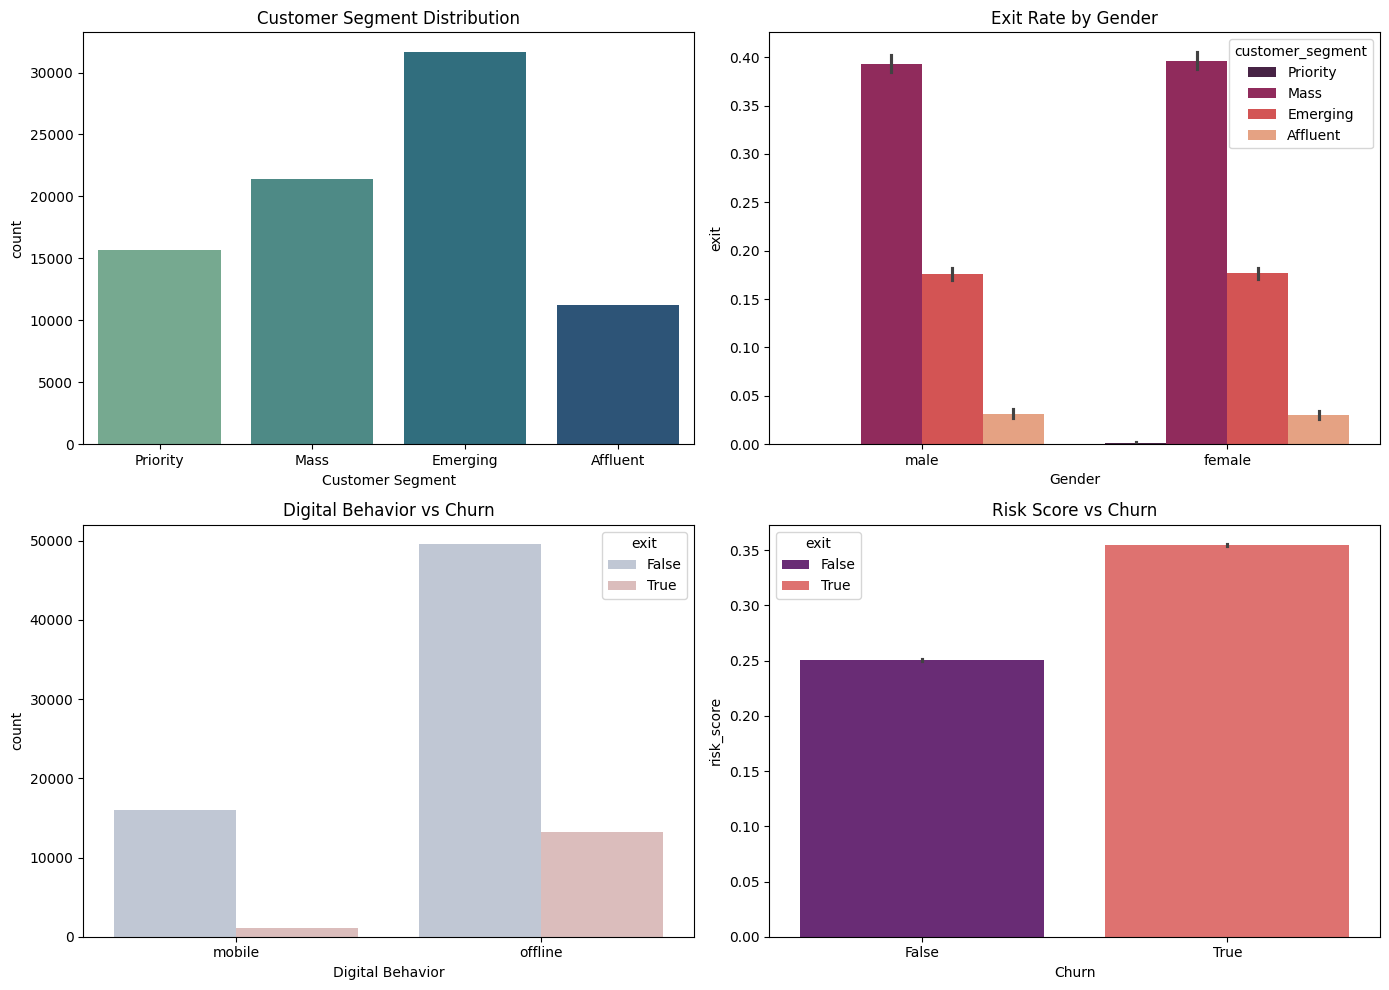

In [63]:
figs, axes = plt.subplots(2 ,2, figsize=(14, 10))

print("Plots to highlight actionable categorical churn drivers")

sns.countplot(data=bank, x='customer_segment', hue='customer_segment', ax=axes[0, 0], palette='crest')
axes[0, 0].set_xlabel("Customer Segment")
axes[0, 0].set_title("Customer Segment Distribution")


sns.barplot(data=bank, x='gender', y='exit', ax=axes[0,1], hue='customer_segment', palette='rocket')
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_title("Exit Rate by Gender")


sns.countplot(data=bank, x='digital_behavior', hue='exit', ax=axes[1, 0], palette='vlag')
axes[1, 0].set_xlabel("Digital Behavior")
axes[1, 0].set_title("Digital Behavior vs Churn")


sns.barplot(data=bank, x='exit', y='risk_score', hue='exit', ax=axes[1, 1], palette='magma')
axes[1, 1].set_xlabel("Churn")
axes[1, 1].set_title("Risk Score vs Churn")


plt.tight_layout()
plt.show()

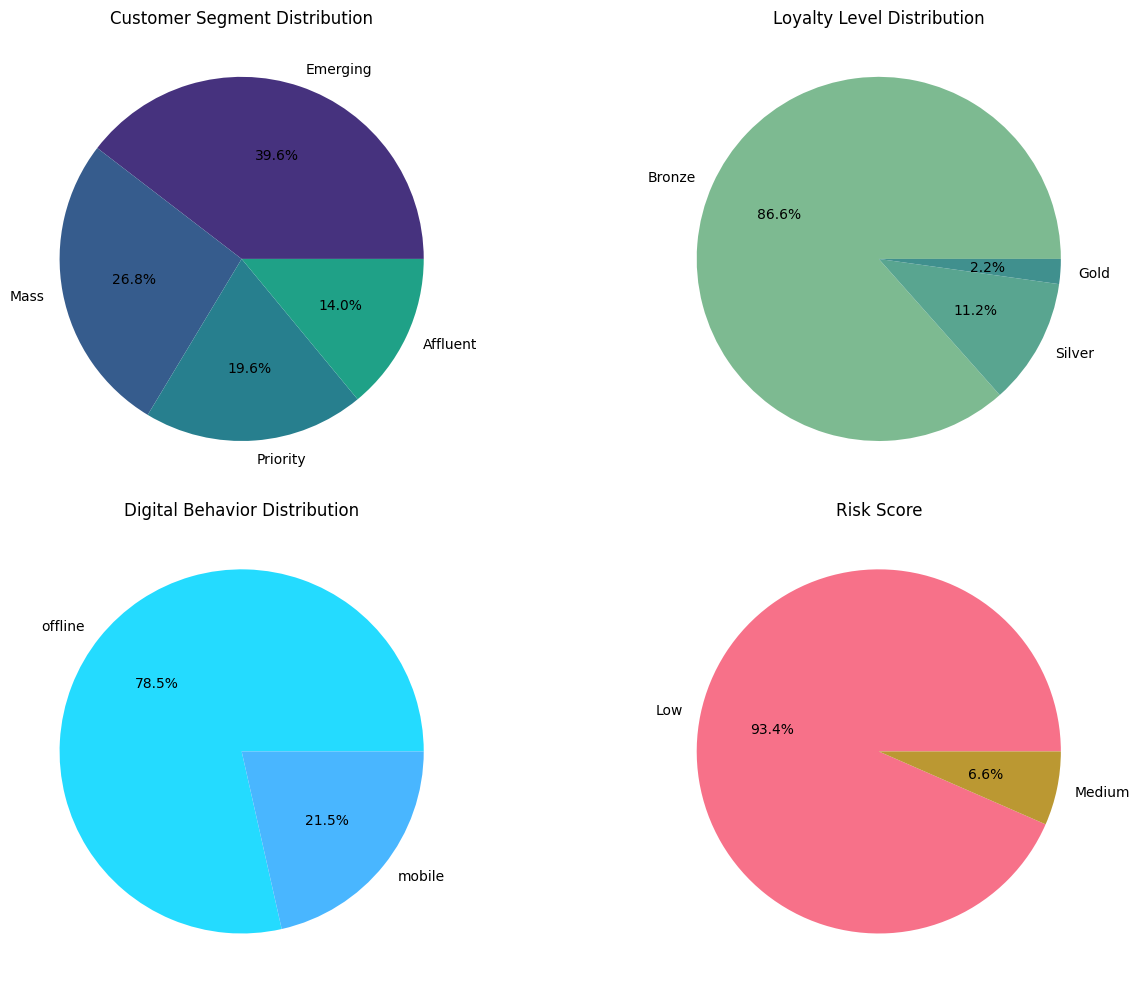

In [64]:
from pandas.core.api import value_counts
figs, axes = plt.subplots(2, 2, figsize=(14, 10))

bank['customer_segment'].value_counts().plot.pie(ax=axes[0, 0], autopct='%1.1f%%', colors = sns.color_palette('viridis'))
axes[0, 0].set_ylabel("")
axes[0, 0].set_title("Customer Segment Distribution")



bank['loyalty_level'].value_counts().plot.pie(ax=axes[0, 1], autopct='%.1f%%', colors = sns.color_palette('crest'))
axes[0, 1].set_ylabel("")
axes[0, 1].set_title("Loyalty Level Distribution")


bank['digital_behavior'].value_counts().plot.pie(ax=axes[1, 0], autopct='%.1f%%', colors = sns.color_palette('cool'))
axes[1, 0].set_ylabel("")
axes[1, 0].set_title("Digital Behavior Distribution")


bank['risk_segment'].value_counts().plot.pie(ax=axes[1, 1], autopct='%.1f%%', colors = sns.color_palette('husl'))
axes[1, 1].set_ylabel("")
axes[1, 1].set_title("Risk Score")


plt.tight_layout()
plt.show()

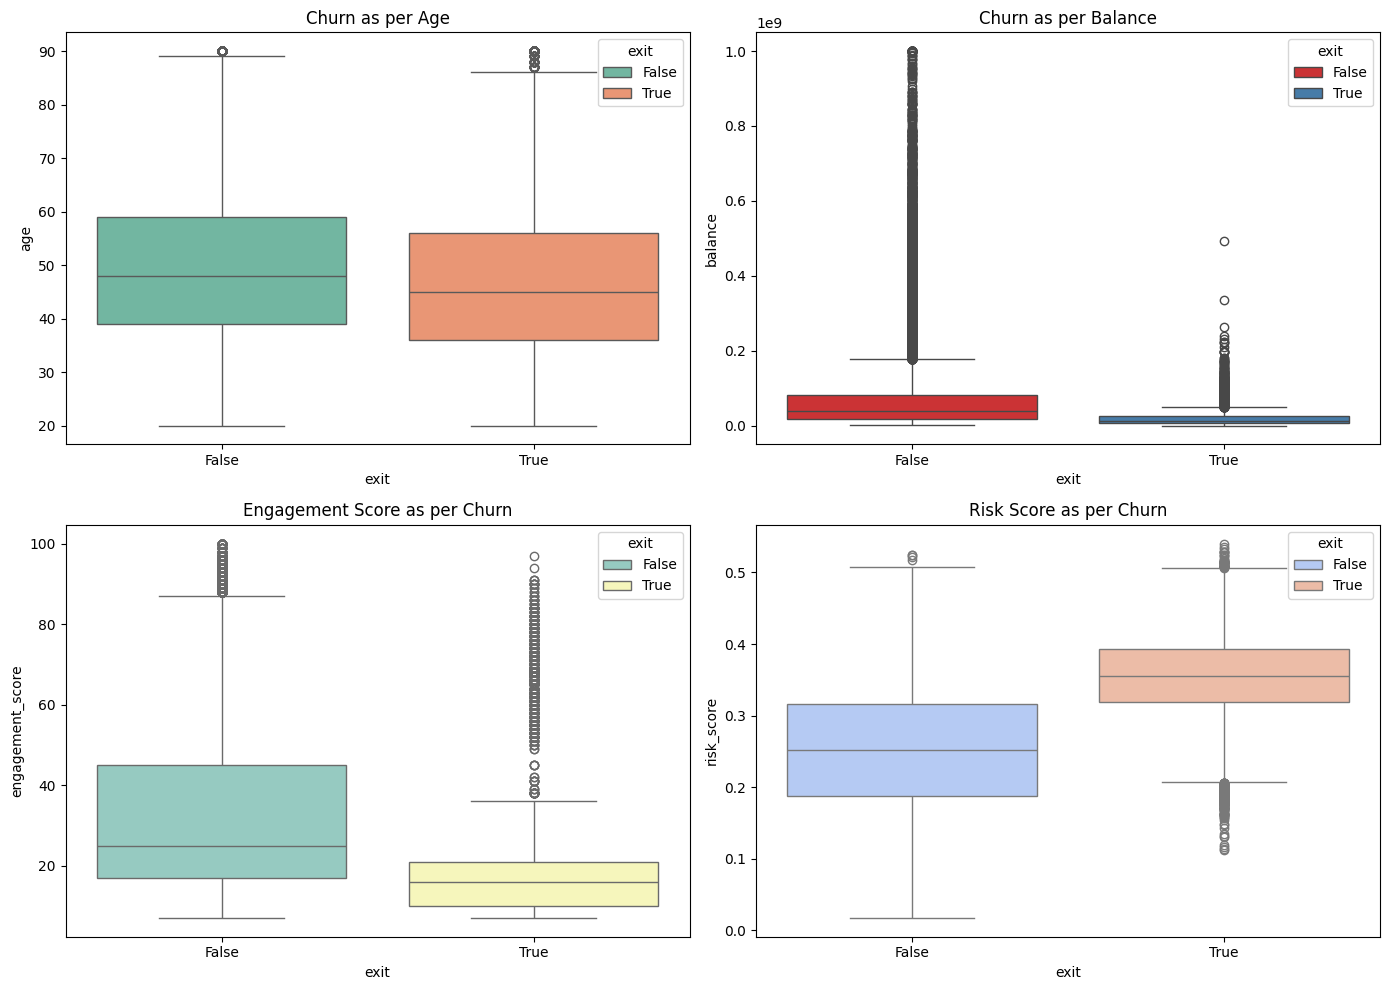

In [65]:
figs, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=bank, x='exit', y='age', hue='exit', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("Churn as per Age")


sns.boxplot(data=bank, x='exit', y='balance', hue='exit', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title("Churn as per Balance")


sns.boxplot(data=bank, y='engagement_score', x='exit', hue='exit', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title("Engagement Score as per Churn")


sns.boxplot(data=bank, y='risk_score', x='exit', hue='exit', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title("Risk Score as per Churn")

plt.tight_layout()
plt.show()

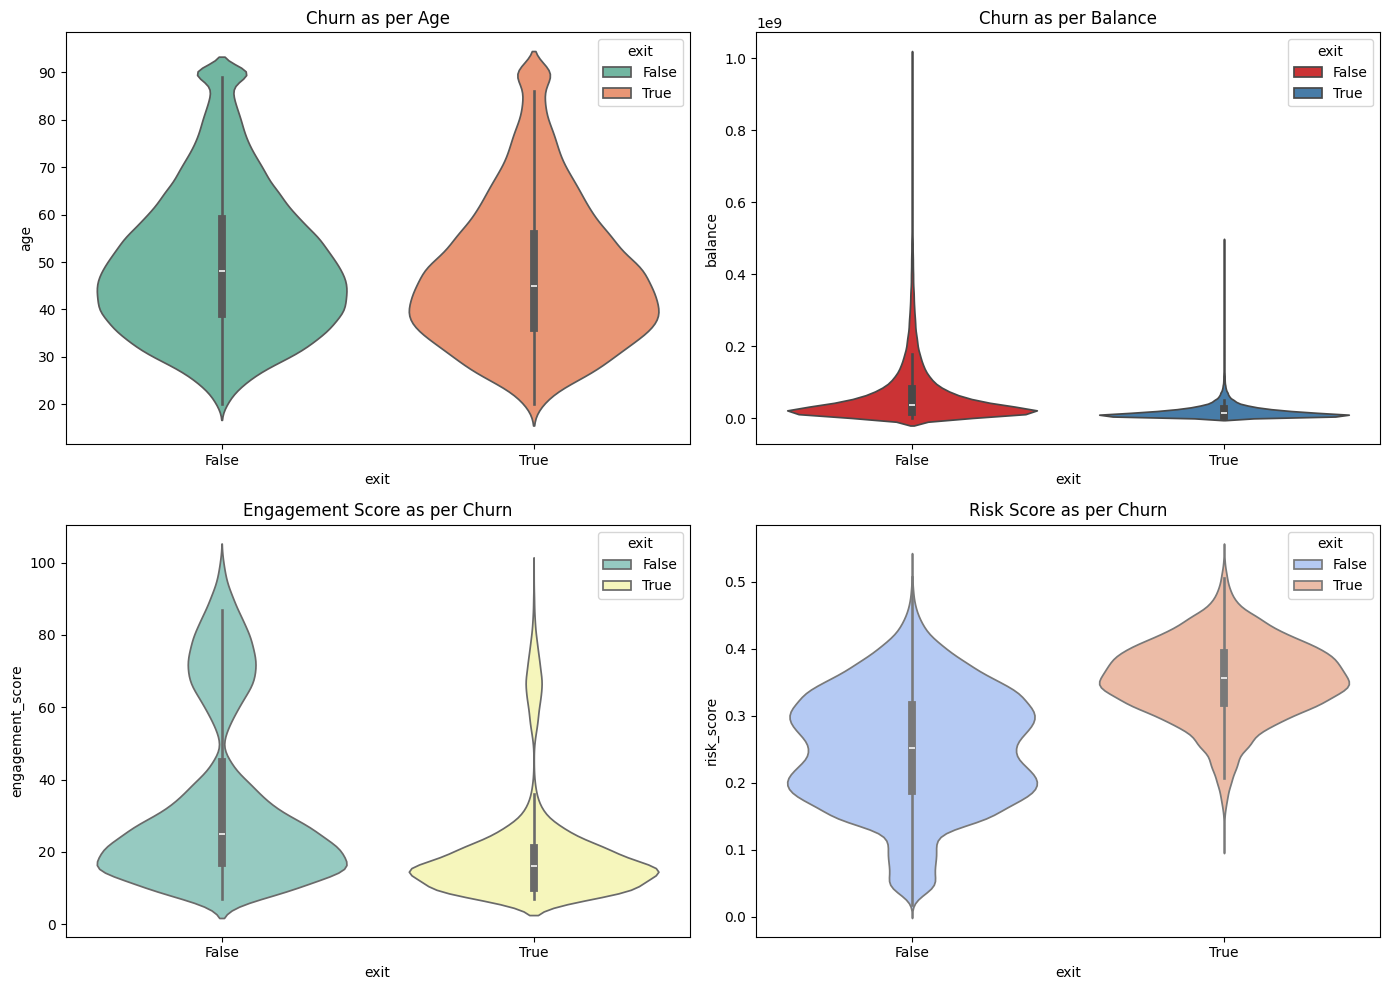

In [66]:
figs, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(data=bank, x='exit', y='age', hue='exit', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title("Churn as per Age")


sns.violinplot(data=bank, x='exit', y='balance', hue='exit', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title("Churn as per Balance")


sns.violinplot(data=bank, y='engagement_score', x='exit', hue='exit', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title("Engagement Score as per Churn")


sns.violinplot(data=bank, y='risk_score', x='exit', hue='exit', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title("Risk Score as per Churn")

plt.tight_layout()
plt.show()

In [67]:
bank.select_dtypes(include='object').columns
cat_cols = ['gender', 'occupation', 'address', 'origin_province',
       'customer_segment', 'loyalty_level', 'digital_behavior',
       'risk_segment', 'married']

encoder = LabelEncoder()
for col in cat_cols:
    bank[col] = encoder.fit_transform(bank[col])
bank.head()

,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,...,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group,engagement_bins
0,1,Đặng Văn Vũ,725,1,55,0,177306004,121000000,4,5,...,2025-02-27,False,3,90,0,0,0.0359,0,4,"(88.375, 100.0]"
1,2,Bùi Hữu Phúc,689,1,45,8,1927416,5000000,5,8,...,2021-07-29,False,2,63,1,0,0.2664,0,2,"(53.5, 65.125]"
2,3,Lê Văn Mai,702,0,44,0,304931745,109000000,7,5,...,2021-03-03,False,3,36,2,1,0.1343,0,4,"(30.25, 41.875]"
3,4,Dương Trần Nhiên,766,1,44,0,50615501,79000000,3,5,...,2022-02-12,False,3,23,0,1,0.2185,0,4,"(18.625, 30.25]"
4,5,Dương Thu Linh,677,0,77,1,40532432,25000000,9,5,...,2022-07-24,False,1,23,0,1,0.2942,0,2,"(18.625, 30.25]"


In [68]:
model = LogisticRegression(max_iter=1000)

scaler = StandardScaler()
bank[bank.select_dtypes(np.number).columns] = scaler.fit_transform(bank[bank.select_dtypes(np.number).columns])

X = bank.drop(columns=['exit'], axis=1).select_dtypes(include=np.number)
y = bank['exit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X, y)

LogisticRegression(max_iter=1000)

In [69]:
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8409375


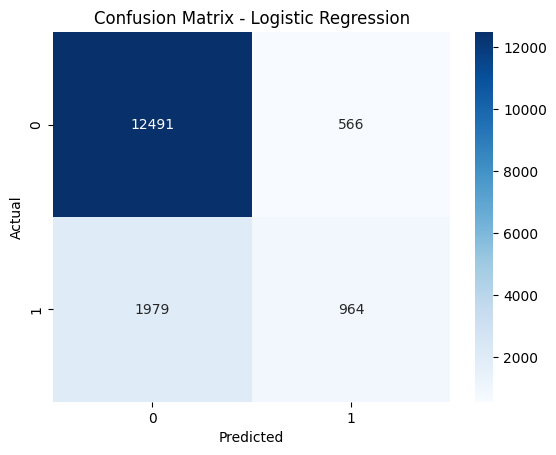

In [70]:
cm = confusion_matrix(y_test, prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

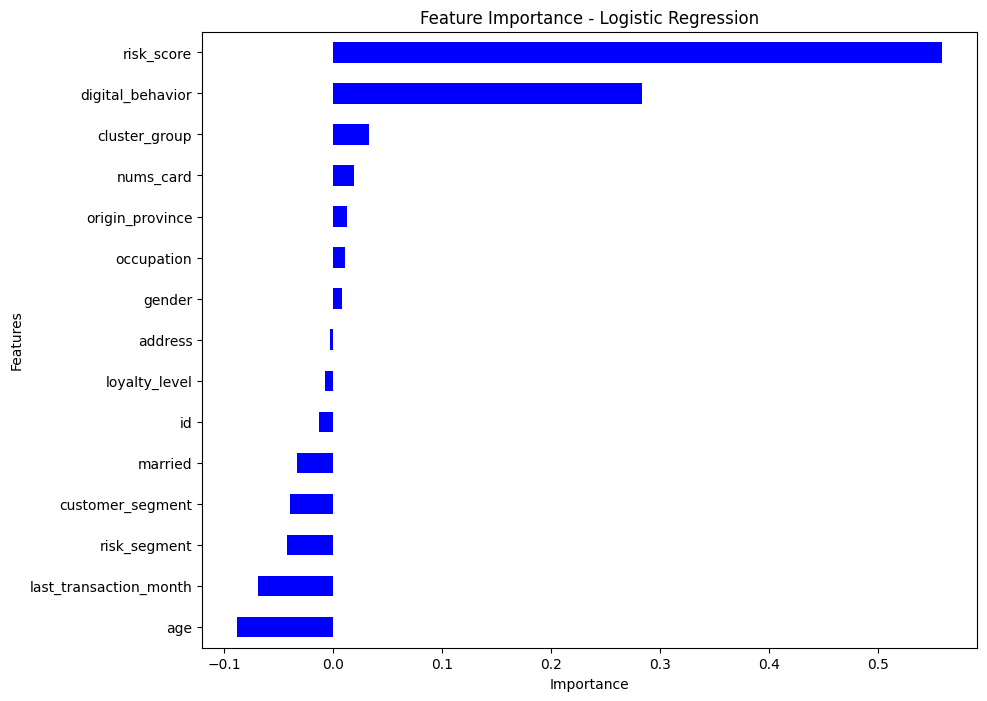

In [71]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

importances = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=True)
importances.tail(15).plot(kind='barh', figsize=(10,8), color='blue')
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [72]:
model = RandomForestClassifier()

scaler = StandardScaler()
bank[bank.select_dtypes(np.number).columns] = scaler.fit_transform(bank[bank.select_dtypes(np.number).columns])

X = bank.drop(columns=['exit'], axis=1).select_dtypes(include=np.number)
y = bank['exit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X, y)

RandomForestClassifier()

In [73]:
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


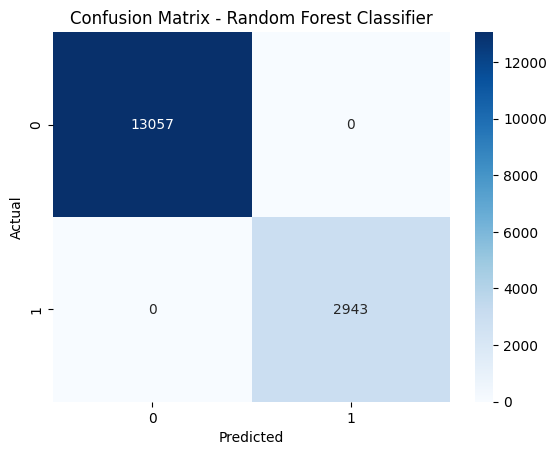

In [74]:
cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

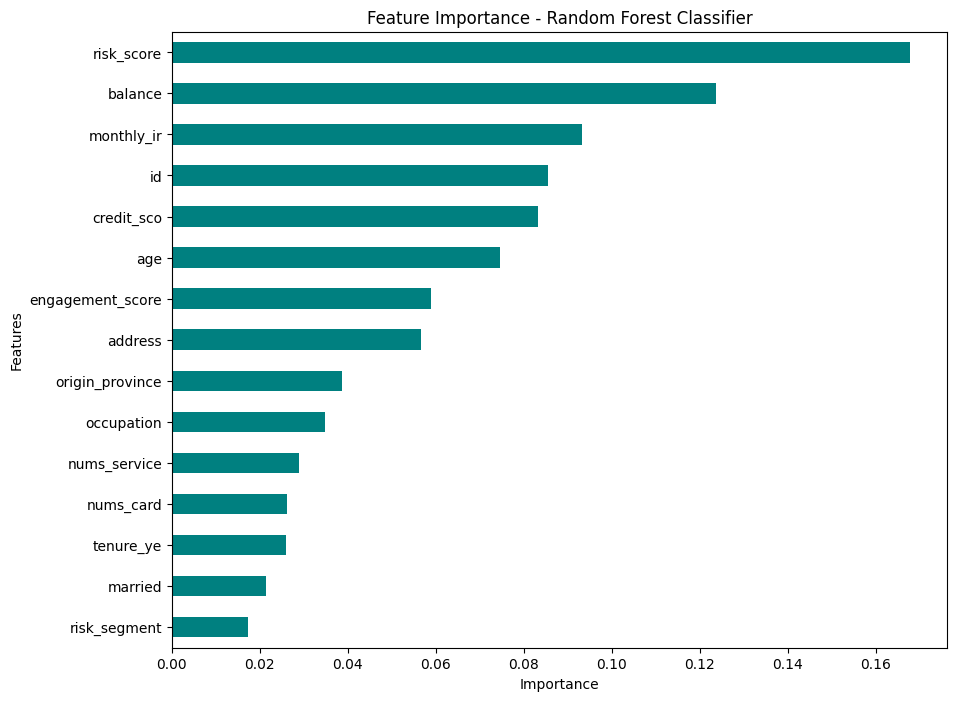

In [75]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(15).plot(kind='barh', figsize=(10,8), color='teal')
plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()